
# Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## download kaggle data to google drive, if data already downloaded, skip this part
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/drive/MyDrive/

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:04<00:00, 38.1MB/s]



In [ ]:
## unzip data, if already unzipped data, skip this part
!unzip /content/drive/MyDrive/brain-tumor-mri-dataset.zip -d /content/brain_tumor_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/brain_

# EDA

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from collections import defaultdict
import random
from torch.utils.data import Dataset
from PIL import Image

Testing: {'notumor': 400, 'glioma': 400, 'meningioma': 400, 'pituitary': 400}
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Training set size: 4480
Validation set size: 1120

Original Training distribution Before Splitting:
Counter({'notumor': 1400, 'glioma': 1400, 'meningioma': 1400, 'pituitary': 1400})

Training distribution:
Counter({'pituitary': 1120, 'notumor': 1120, 'glioma': 1120, 'meningioma': 1120})

Validation distribution:
Counter({'glioma': 280, 'meningioma': 280, 'pituitary': 280, 'notumor': 280})


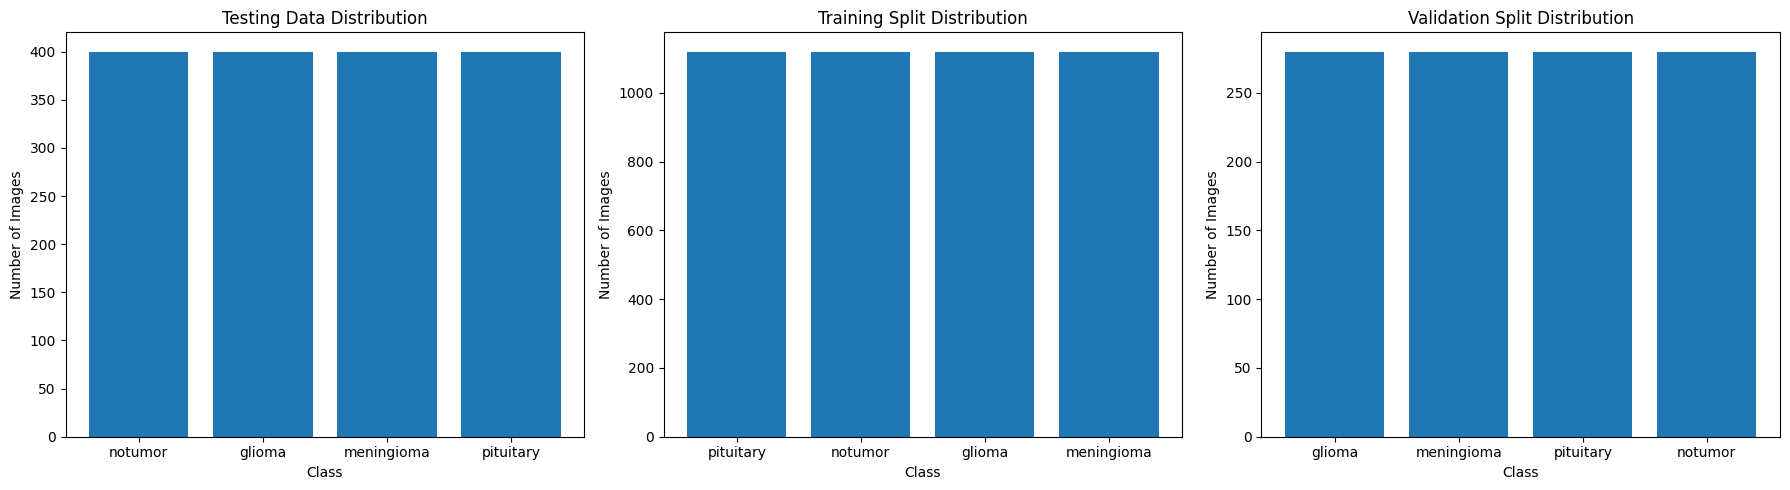

In [ ]:
train_dir = "/content/brain_tumor_data/Training"
test_dir = "/content/brain_tumor_data/Testing"

# ---------------------------
# Count testing set per class
# ---------------------------

test_paths =  []
test_labels = []

test_classes = [
    cls for cls in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, cls))
]

for label in test_classes:
    class_path = os.path.join(test_dir, label)

    for img_name in os.listdir(class_path):
        test_paths.append(os.path.join(class_path, img_name))
        test_labels.append(label)

test_class_counts = {
    cls: len(os.listdir(os.path.join(test_dir, cls)))
    for cls in test_classes
}

print("Testing:", test_class_counts)

# ---------------------------
# Collect training image paths and labels
# ---------------------------
image_paths = []
labels = []

train_classes = [
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
]

for label in train_classes:
    class_path = os.path.join(train_dir, label)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        image_paths.append(img_path)
        labels.append(label)

# ---------------------------
# Stratified split
# ---------------------------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)


# ---------------------------
# Create train and validation datasets
# ---------------------------

class MRIDataset(Dataset):
    def __init__(self, paths, labels, label_to_idx, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("L")
        label = self.label_to_idx[self.labels[idx]]

        if self.transform:
            image = self.transform(image)

        return image, label

classes = sorted(set(labels))   # labels = original full dataset labels
label_to_idx = {cls: i for i, cls in enumerate(classes)}

print(label_to_idx)


# ---------------------------
# Count class distributions
# ---------------------------
original_counts = Counter(labels)
train_class_counts = Counter(train_labels)
val_class_counts = Counter(val_labels)

print("\nTraining set size:", len(train_paths))
print("Validation set size:", len(val_paths))

print("\nOriginal Training distribution Before Splitting:")
print(original_counts)

print("\nTraining distribution:")
print(train_class_counts)

print("\nValidation distribution:")
print(val_class_counts)

# ---------------------------
# Plot distributions
# ---------------------------
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.bar(test_class_counts.keys(), test_class_counts.values())
plt.title("Testing Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.subplot(1, 3, 2)
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.title("Training Split Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.subplot(1, 3, 3)
plt.bar(val_class_counts.keys(), val_class_counts.values())
plt.title("Validation Split Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

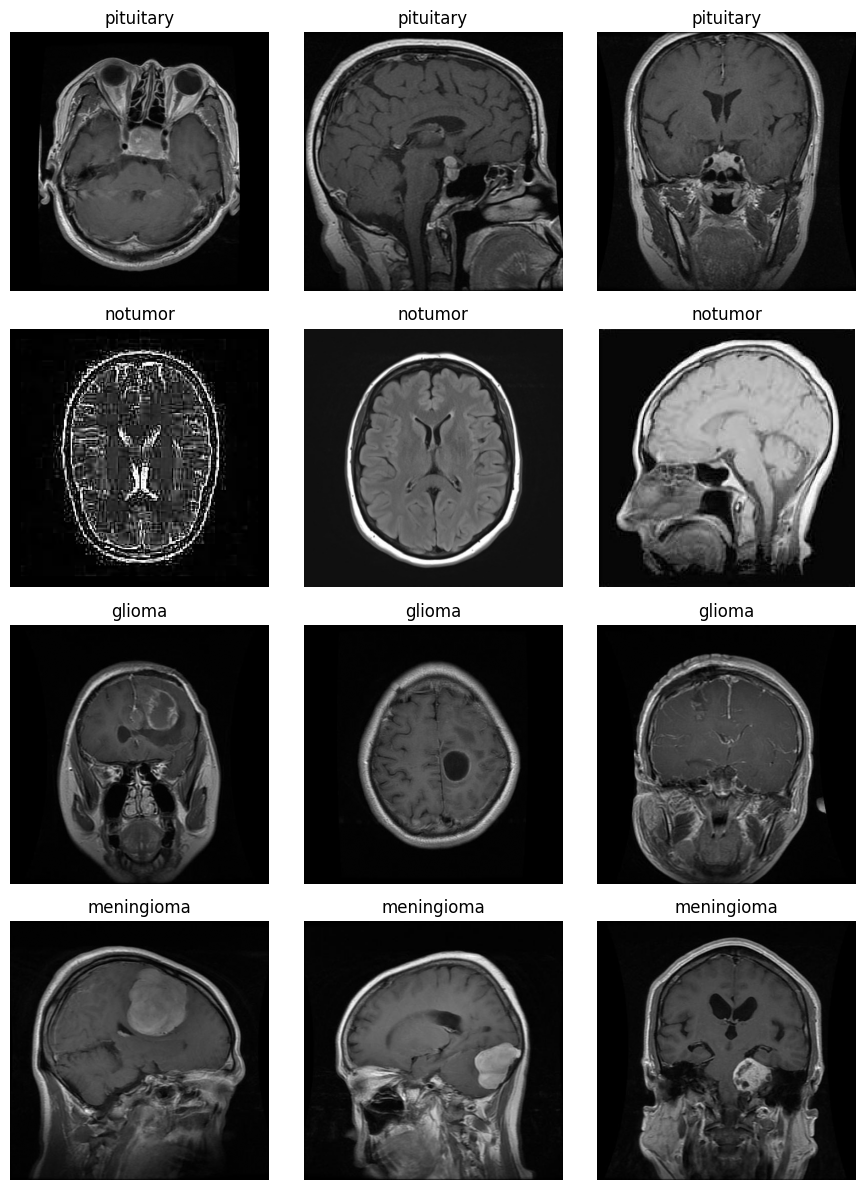

In [ ]:
def show_random_images(paths, labels, num_per_class=3):

    # group images by class
    class_to_images = defaultdict(list)

    for path, label in zip(paths, labels):
        class_to_images[label].append(path)

    classes = list(class_to_images.keys())

    plt.figure(figsize=(num_per_class * 3, len(classes) * 3))

    plot_index = 1

    for cls in classes:
        images = class_to_images[cls]

        selected = random.sample(images, min(len(images), num_per_class))

        for img_path in selected:
            img = Image.open(img_path)

            plt.subplot(len(classes), num_per_class, plot_index)
            plt.imshow(img, cmap='gray')
            plt.title(cls)
            plt.axis('off')

            plot_index += 1

    plt.tight_layout()
    plt.show()

show_random_images(train_paths, train_labels, num_per_class=3)

# Data preprocessing

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms

testset shape: torch.Size([1, 224, 224])
trainset shape: torch.Size([1, 224, 224])
valset shape: torch.Size([1, 224, 224])
train_labels[0] = pituitary
decoded label   = pituitary
val_labels[0]   = glioma
decoded label   = glioma
test_labels[0]  = notumor
decoded label   = notumor


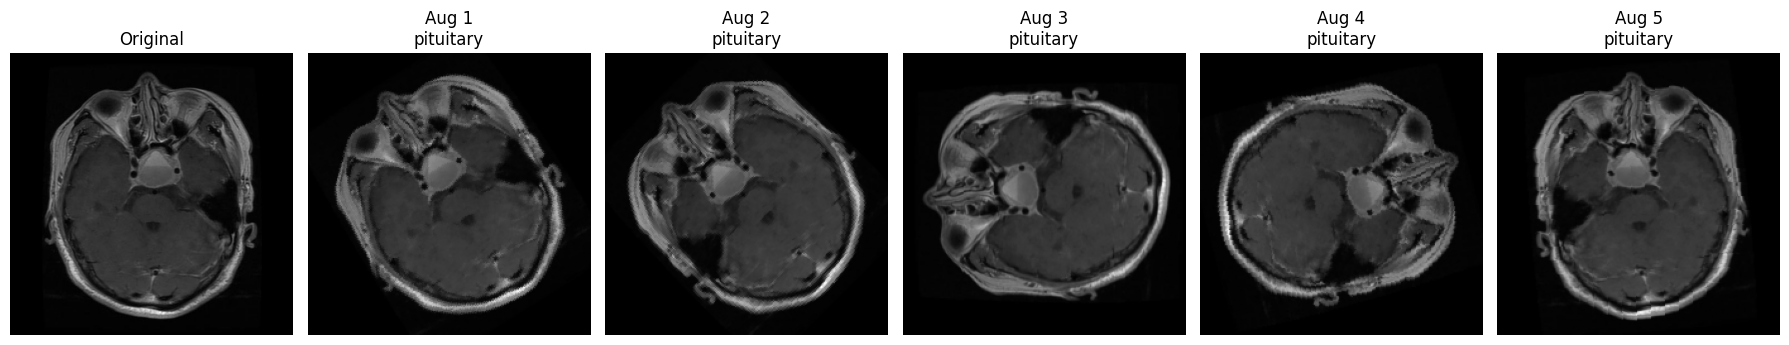

Same label: True
Exactly same tensor: False


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(100),      # augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),      # only preprocessing
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = MRIDataset(
    train_paths,
    train_labels,
    label_to_idx,
    transform=train_transform
)

val_dataset = MRIDataset(
    val_paths,
    val_labels,
    label_to_idx,
    transform=val_transform
)

test_dataset = MRIDataset(
    test_paths,
    test_labels,
    label_to_idx,
    transform=test_transform
)


# check shape

img, label = test_dataset[0]

print("testset shape:", img.shape)   # [1, 224, 224]


img, label = train_dataset[0]

print("trainset shape:", img.shape)   # should be [1, 224, 224]


img, label = val_dataset[0]

print("valset shape:", img.shape)   # should be [1, 224, 224]

# check label decoding

idx_to_label = {v: k for k, v in label_to_idx.items()}
# train
img, label_num = train_dataset[0]
print("train_labels[0] =", train_labels[0])
print("decoded label   =", idx_to_label[label_num])

# val
img, label_num = val_dataset[0]
print("val_labels[0]   =", val_labels[0])
print("decoded label   =", idx_to_label[label_num])

# test
img, label_num = test_dataset[0]
print("test_labels[0]  =", test_labels[0])
print("decoded label   =", idx_to_label[label_num])

# check augmentation
def show_augmentation(dataset, paths, index=0, num_versions=5):
    original_img = Image.open(paths[index])

    plt.figure(figsize=(3 * (num_versions + 1), 4))

    # original
    plt.subplot(1, num_versions + 1, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # augmented versions
    for i in range(num_versions):
        img, label = dataset[index]

        # undo normalization for display
        img = img * 0.5 + 0.5
        img = img.squeeze().numpy()

        plt.subplot(1, num_versions + 1, i + 2)
        plt.imshow(img, cmap='gray')
        plt.title(f"Aug {i+1}\n{idx_to_label[label]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_augmentation(train_dataset, train_paths, index=0, num_versions=5)

img1, label1 = train_dataset[0]
img2, label2 = train_dataset[0]

print("Same label:", label1 == label2)
print("Exactly same tensor:", (img1 == img2).all().item())

# Baseline model

In [ ]:
import torch
import torch.nn as nn
import copy

In [ ]:

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # input: [batch, 1, 224, 224]
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # -> [16, 112, 112]

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # -> [32, 56, 56]

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)    # -> [64, 28, 28]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=4)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

cuda


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

images, labels = next(iter(train_loader))
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 1, 224, 224])
Output shape: torch.Size([64, 4])


In [ ]:
model.train()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)
loss = criterion(outputs, labels)

loss.backward()
optimizer.step()

print("Loss:", loss.item())

Loss: 1.393173336982727


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(dataloader)}")

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
num_epochs = 40

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # save accuracy/loss history every epoch
    # torch.save(train_accuracies, '/content/drive/MyDrive/train_acc.pth')
    # torch.save(val_accuracies, '/content/drive/MyDrive/val_acc.pth')

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    # save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, '/content/best_baseline_model.pth')
        print("Best model updated!")

# load best model weights back into model
model.load_state_dict(best_model_wts)
print(f"Loaded best model with validation accuracy: {best_val_acc:.4f}")

Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [1/40]
Train Loss: 0.9095, Train Acc: 0.6272
Val   Loss: 0.6860, Val   Acc: 0.7098
Best model updated!
Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [2/40]
Train Loss: 0.6172, Train Acc: 0.7549
Val   Loss: 0.6063, Val   Acc: 0.7696
Best model updated!
Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [3/40]
Train Loss: 0.5492, Train Acc: 0.7812
Val   Loss: 0.5332, Val   Acc: 0.8018
Best model updated!
Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [4/40]
Train Loss: 0.5128, Train Acc: 0.8045
Val   Loss: 0.4931, Val   Acc: 0.8205
Best model updated!
Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [5/40]
Train Loss: 0.4564, Train Acc: 0.8246
Val   Loss: 0.5683, Val   Acc: 0.7634
Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [6/40]
Train Loss: 0.4298, Train Acc: 0.8353
Val   Loss: 0.4801, Val   Acc: 0.8223
Best model updated!
Batch 0/70
Batch 20/70
Batch 40/70
Batch 60/70
Epoch [7/40]
Train Loss: 0.3872, Trai

In [ ]:
!cp /content/best_baseline_model.pth /content/drive/MyDrive/

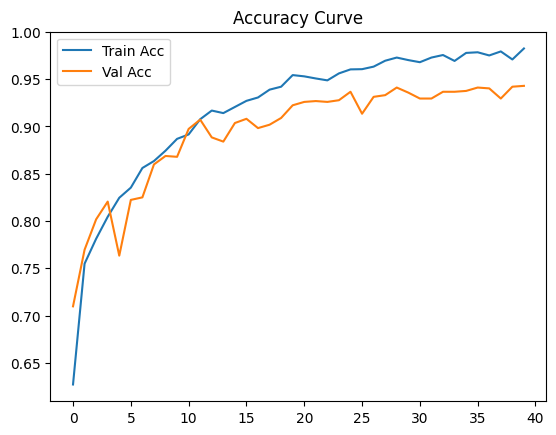

In [ ]:
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()